# Lab 9- Deep Learning Model

This lab is meant to get you started in using Keras to design Deep Neural Networks. The goal here is to simply repeat your previous lab, but with DNNs.

Let's start with reading the data, like before:

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

filename= "/mnt/c/Users/mahim/DATA3402.Spring.2026/Labs/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi","MET", "MET_phi", "MET_rel", "axial_MET"]
FeatureNames=["M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype='float64', names=VarNames)

Now lets define training and test samples. Note that DNNs take very long to train, so for testing purposes we will use only about 10% of the 5 million events in the training/validation sample. Once you get everything working, make the final version of your plots with the full sample. 

Also note that Keras had trouble with the Pandas tensors, so after doing all of the nice manipulation that Pandas enables, we convert the Tensor to a regular numpy tensor.

In [7]:
N_Max   = 550000
N_Train = 500000

Train_Sample = df[:N_Train]
Test_Sample  = df[N_Train:N_Max]

X_Train_all = np.array(Train_Sample[VarNames[1:]])
y_Train     = np.array(Train_Sample["signal"])
X_Test_all  = np.array(Test_Sample[VarNames[1:]])
y_Test      = np.array(Test_Sample["signal"])

X_Train_raw  = np.array(Train_Sample[RawNames])
X_Test_raw   = np.array(Test_Sample[RawNames])

X_Train_feat = np.array(Train_Sample[FeatureNames])
X_Test_feat  = np.array(Test_Sample[FeatureNames])


## Exercise 1

You will need to create several models and make sure they are properly trained. Write a function that takes this history and plots the values versus epoch. For every model that you train in the remainder of this lab, assess:

* Has you model's performance plateaued? If not train for more epochs. 
* Compare the performance on training versus test sample. Are you over training?

## Exercise 2

Following the original paper (see lab 7), make a comparison of the performance (using ROC curves and AUC) between models trained with raw, features, and raw+features data.

## Exercise 3

Design and implement at least 3 different DNN models. Train them and compare performance. You may try different architectures, loss functions, and optimizers to see if there is an effect.

## Exercise 4

Repeat exercise 4 from Lab 8, adding your best performing DNN as one of the models.  


In [4]:
import os
for root, dirs, files in os.walk("/mnt/c/Users/mahim/DATA3402.Spring.2026"):
    for f in files:
        if f == "SUSY.csv":
            print(os.path.join(root, f))

/mnt/c/Users/mahim/DATA3402.Spring.2026/Labs/SUSY.csv


In [5]:
#1

def plot_history(history, title="Model Training History"):
    hist   = history.history
    epochs = range(1, len(hist['loss']) + 1)

    # Searching whichever metric was tracked
    metric_key = None
    for key in ['auc', 'accuracy', 'acc']:
        if key in hist:
            metric_key = key
            break

    n_plots = 2 if metric_key else 1
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 4))
    if n_plots == 1:
        axes = [axes]

    # Loss
    axes[0].plot(epochs, hist['loss'],     label='Train Loss')
    axes[0].plot(epochs, hist['val_loss'], label='Val Loss', linestyle='--')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss')
    axes[0].legend()

    # Metric (AUC or accuracy)
    if metric_key:
        val_key = f'val_{metric_key}'
        axes[1].plot(epochs, hist[metric_key], label=f'Train {metric_key.upper()}')
        axes[1].plot(epochs, hist[val_key],    label=f'Val {metric_key.upper()}', linestyle='--')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel(metric_key.upper())
        axes[1].set_title(metric_key.upper())
        axes[1].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

    # Plateau check
    last5 = hist['val_loss'][-5:]
    delta = max(last5) - min(last5)
    print(f"Last 5 val_loss range: {delta:.5f} — ", end="")
    if delta < 1e-4:
        print("Model appears to have plateaued. ✓")
    else:
        print("Model may still be improving — consider more epochs.")

    # Overtraining check
    gap = hist['val_loss'][-1] - hist['loss'][-1]
    print(f"Final train/val loss gap: {gap:.5f} — ", end="")
    if gap > 0.01:
        print("Possible overfitting detected.")
    else:
        print("No significant overfitting. ✓")

=== RAW features ===


E0000 00:00:1776918047.258061   11520 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - auc: 0.8623 - loss: 0.4490 - val_auc: 0.8675 - val_loss: 0.4452
Epoch 2/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - auc: 0.8694 - loss: 0.4376 - val_auc: 0.8709 - val_loss: 0.4375
Epoch 3/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - auc: 0.8724 - loss: 0.4329 - val_auc: 0.8724 - val_loss: 0.4334
Epoch 4/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - auc: 0.8736 - loss: 0.4309 - val_auc: 0.8741 - val_loss: 0.4316
Epoch 5/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - auc: 0.8746 - loss: 0.4294 - val_auc: 0.8739 - val_loss: 0.4307
Epoch 6/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - auc: 0.8751 - loss: 0.4285 - val_auc: 0.8748 - val_loss: 0.4303
Epoch 7/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - auc: 0.8756 - loss: 0.4278 - val_auc: 0.8739 - val_loss: 0.4315
Epoch 8/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - auc: 0.8758 - loss: 0.4274 - val_auc: 0.8750 - val_loss: 0.4294
Epoch 9/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - au

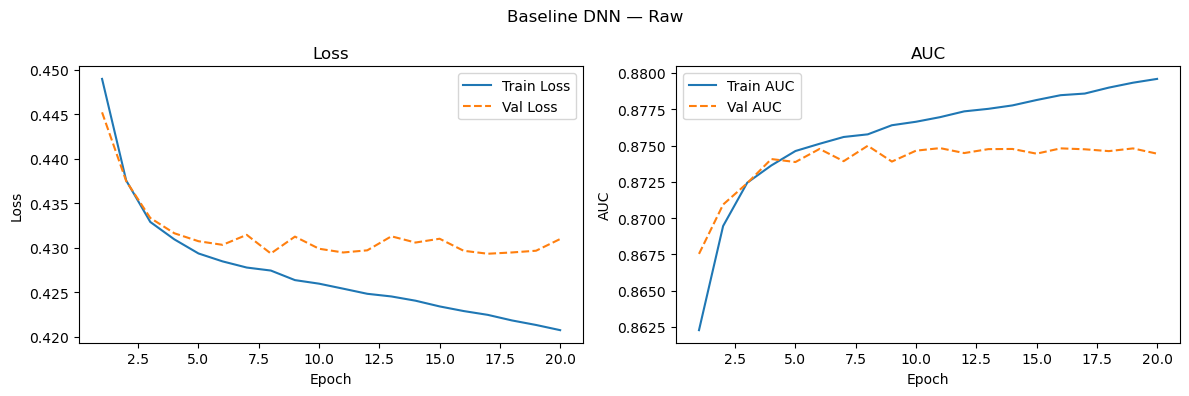

Last 5 val_loss range: 0.00166 — Model may still be improving — consider more epochs.
Final train/val loss gap: 0.01024 — Possible overfitting detected.

=== HIGH-LEVEL features ===
Epoch 1/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - auc: 0.8433 - loss: 0.4779 - val_auc: 0.8557 - val_loss: 0.4595
Epoch 2/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.8544 - loss: 0.4602 - val_auc: 0.8586 - val_loss: 0.4567
Epoch 3/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - auc: 0.8564 - loss: 0.4569 - val_auc: 0.8583 - val_loss: 0.4545
Epoch 4/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - auc: 0.8575 - loss: 0.4550 - val_auc: 0.8591 - val_loss: 0.4542
Epoch 5/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - auc: 0.8586 - loss: 0.4534 - val_auc: 0.8605 - val_loss: 0.4522
Epoch 6/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - auc: 0.8585 - loss: 0.4530 - val_auc: 0.8602 - val_loss: 0.4516
Epoch 7/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - auc: 0.8595 - loss: 0.4515 - val_auc: 0.8604 - val_los

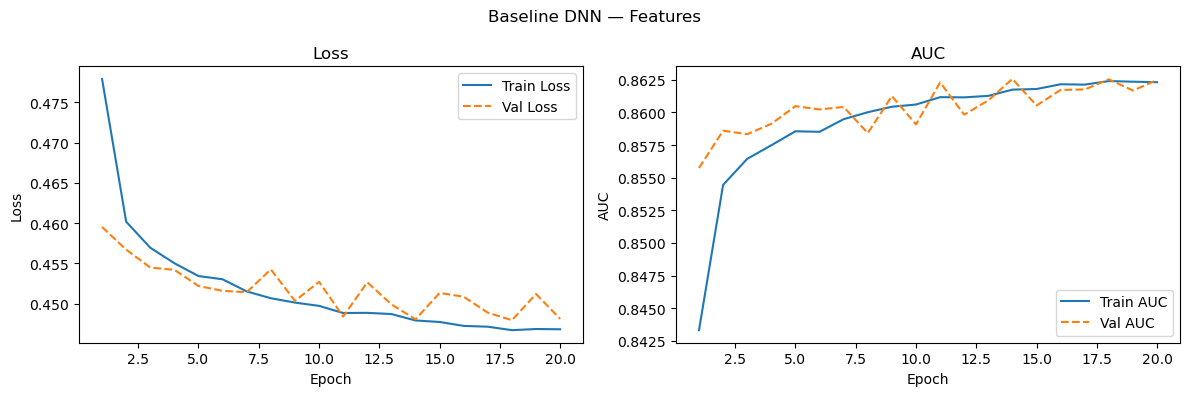

Last 5 val_loss range: 0.00325 — Model may still be improving — consider more epochs.
Final train/val loss gap: 0.00129 — No significant overfitting. ✓

=== RAW + FEATURES ===
Epoch 1/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - auc: 0.8682 - loss: 0.4394 - val_auc: 0.8731 - val_loss: 0.4326
Epoch 2/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - auc: 0.8736 - loss: 0.4307 - val_auc: 0.8740 - val_loss: 0.4306
Epoch 3/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - auc: 0.8749 - loss: 0.4288 - val_auc: 0.8747 - val_loss: 0.4298
Epoch 4/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - auc: 0.8756 - loss: 0.4276 - val_auc: 0.8748 - val_loss: 0.4295
Epoch 5/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - auc: 0.8763 - loss: 0.4266 - val_auc: 0.8755 - val_loss: 0.4296
Epoch 6/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - auc: 0.8766 - loss: 0.4260 - val_auc: 0.8752 - val_loss: 0.4295
Epoch 7/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - auc: 0.8772 - loss: 0.4252 - val_auc: 0.8760 - val_loss: 0.427

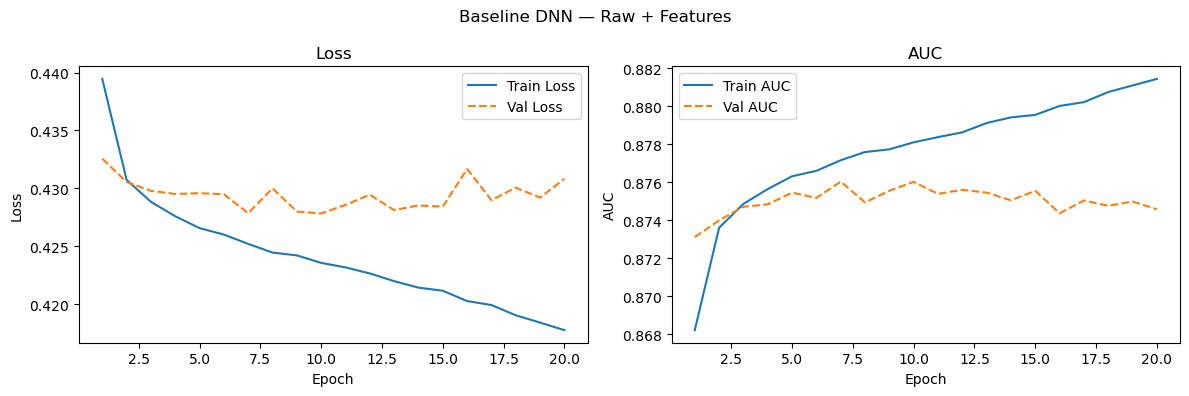

Last 5 val_loss range: 0.00269 — Model may still be improving — consider more epochs.
Final train/val loss gap: 0.01306 — Possible overfitting detected.


In [9]:
#2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler

def scale(X_tr, X_te):
    sc = StandardScaler()
    return sc.fit_transform(X_tr), sc.transform(X_te)

X_Train_raw_s,  X_Test_raw_s  = scale(X_Train_raw,  X_Test_raw)
X_Train_feat_s, X_Test_feat_s = scale(X_Train_feat, X_Test_feat)
X_Train_all_s,  X_Test_all_s  = scale(X_Train_all,  X_Test_all)

def build_baseline_dnn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(300, activation='relu'),
        layers.Dense(300, activation='relu'),
        layers.Dense(300, activation='relu'),
        layers.Dense(1,   activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')]
    )
    return model

FIT_KWARGS = dict(epochs=20, batch_size=1024, validation_split=0.1, verbose=1)

print("=== RAW features ===")
model_raw = build_baseline_dnn(X_Train_raw_s.shape[1])
history_raw = model_raw.fit(X_Train_raw_s, y_Train, **FIT_KWARGS)
plot_history(history_raw, "Baseline DNN — Raw")

print("\n=== HIGH-LEVEL features ===")
model_feat = build_baseline_dnn(X_Train_feat_s.shape[1])
history_feat = model_feat.fit(X_Train_feat_s, y_Train, **FIT_KWARGS)
plot_history(history_feat, "Baseline DNN — Features")

print("\n=== RAW + FEATURES ===")
model_all = build_baseline_dnn(X_Train_all_s.shape[1])
history_all = model_all.fit(X_Train_all_s, y_Train, **FIT_KWARGS)
plot_history(history_all, "Baseline DNN — Raw + Features")

# claude helped with planning the code, mine was a bit disorganized

In [11]:
!pip install tensorflow --break-system-packages


Defaulting to user installation because normal site-packages is not writeable


=== Model A: Wide & Shallow ===


Model: "ModelA_Wide_Shallow"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │         9,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 272,897 (1.04 MB)

 Trainable params: 272,897 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - auc: 0.8685 - loss: 0.4391 - val_auc: 0.8734 - val_loss: 0.4315
Epoch 2/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - auc: 0.8735 - loss: 0.4307 - val_auc: 0.8743 - val_loss: 0.4300
Epoch 3/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - auc: 0.8748 - loss: 0.4288 - val_auc: 0.8743 - val_loss: 0.4303
Epoch 4/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - auc: 0.8757 - loss: 0.4276 - val_auc: 0.8752 - val_loss: 0.4299
Epoch 5/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - auc: 0.8763 - loss: 0.4267 - val_auc: 0.8750 - val_loss: 0.4299
Epoch 6/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - auc: 0.8766 - loss: 0.4261 - val_auc: 0.8753 - val_loss: 0.4289
Epoch 7/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - auc: 0.8771 - loss: 0.4253 - val_auc: 0.8758 - val_loss: 0.4280
Epoch 8/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - auc: 0.8772 - loss: 0.4250 - val_auc: 0.8756 - val_loss: 0.4281
Epoch 9/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/s

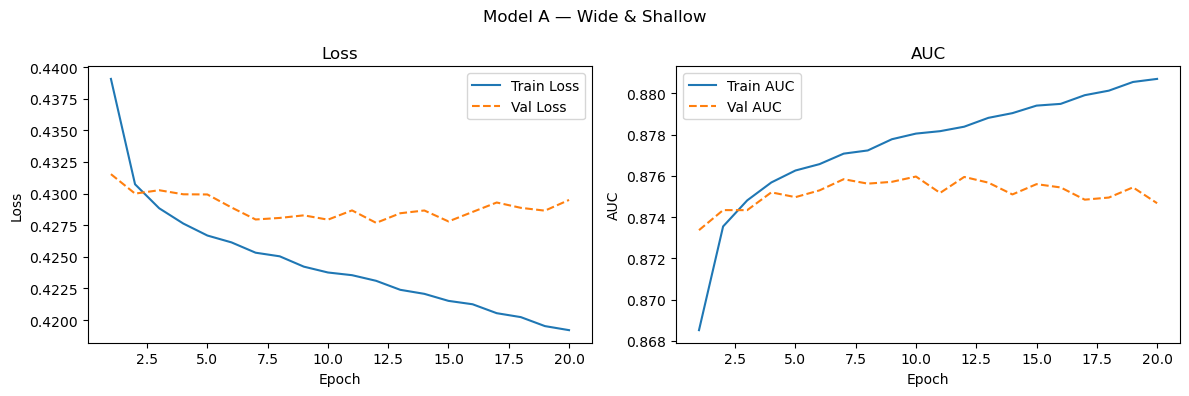

Last 5 val_loss range: 0.00095 — Model may still be improving — consider more epochs.
Final train/val loss gap: 0.01030 — Possible overfitting detected.

=== Model B: Deep with Dropout ===


Model: "ModelB_Deep_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 256)            │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177,665 (694.00 KB)

 Trainable params: 177,665 (694.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - auc: 0.8580 - loss: 0.4550 - val_auc: 0.8717 - val_loss: 0.4356
Epoch 2/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - auc: 0.8687 - loss: 0.4383 - val_auc: 0.8735 - val_loss: 0.4329
Epoch 3/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - auc: 0.8708 - loss: 0.4353 - val_auc: 0.8739 - val_loss: 0.4350
Epoch 4/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - auc: 0.8718 - loss: 0.4336 - val_auc: 0.8748 - val_loss: 0.4322
Epoch 5/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - auc: 0.8724 - loss: 0.4328 - val_auc: 0.8748 - val_loss: 0.4334
Epoch 6/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - auc: 0.8731 - loss: 0.4319 - val_auc: 0.8755 - val_loss: 0.4297
Epoch 7/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - auc: 0.8735 - loss: 0.4312 - val_auc: 0.8758 - val_loss: 0.4281
Epoch 8/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - auc: 0.8740 - loss: 0.4304 - val_auc: 0.8755 - val_loss: 0.4287
Epoch 9/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/st

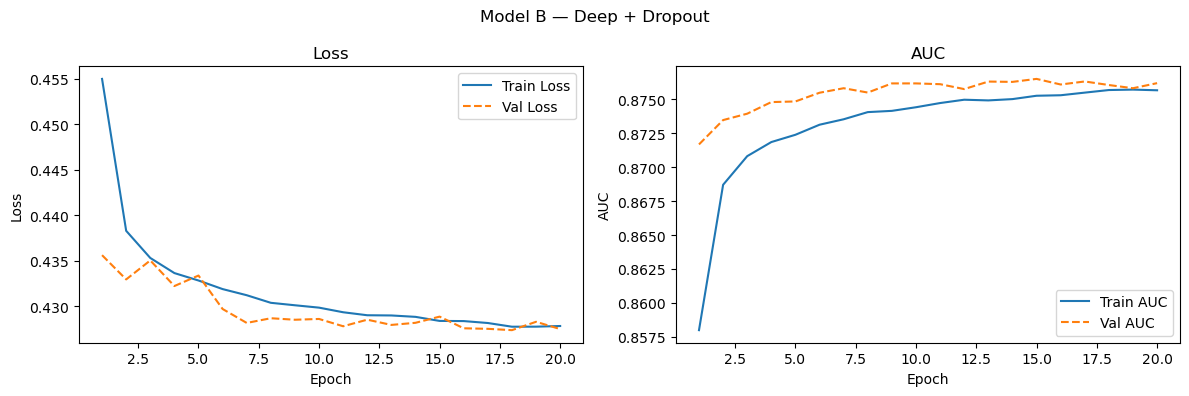

Last 5 val_loss range: 0.00092 — Model may still be improving — consider more epochs.
Final train/val loss gap: -0.00034 — No significant overfitting. ✓

=== Model C: BatchNorm + RMSprop + L2 ===


Model: "ModelC_BatchNorm_RMSprop_L2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 300)            │         5,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300)            │         1,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 300)            │         1,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 300)            │         1,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │           301 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 190,201 (742.97 KB)

 Trainable params: 188,401 (735.94 KB)

 Non-trainable params: 1,800 (7.03 KB)

Epoch 1/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - auc: 0.8641 - loss: 0.5035 - val_auc: 0.8710 - val_loss: 0.4824
Epoch 2/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - auc: 0.8728 - loss: 0.4709 - val_auc: 0.8705 - val_loss: 0.4675
Epoch 3/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - auc: 0.8744 - loss: 0.4562 - val_auc: 0.8721 - val_loss: 0.4571
Epoch 4/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - auc: 0.8749 - loss: 0.4474 - val_auc: 0.8747 - val_loss: 0.4461
Epoch 5/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - auc: 0.8752 - loss: 0.4418 - val_auc: 0.8729 - val_loss: 0.4451
Epoch 6/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - auc: 0.8756 - loss: 0.4381 - val_auc: 0.8732 - val_loss: 0.4415
Epoch 7/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - auc: 0.8759 - loss: 0.4357 - val_auc: 0.8748 - val_loss: 0.4375
Epoch 8/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - auc: 0.8759 - loss: 0.4343 - val_auc: 0.8745 - val_loss: 0.4361
Epoch 9/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms

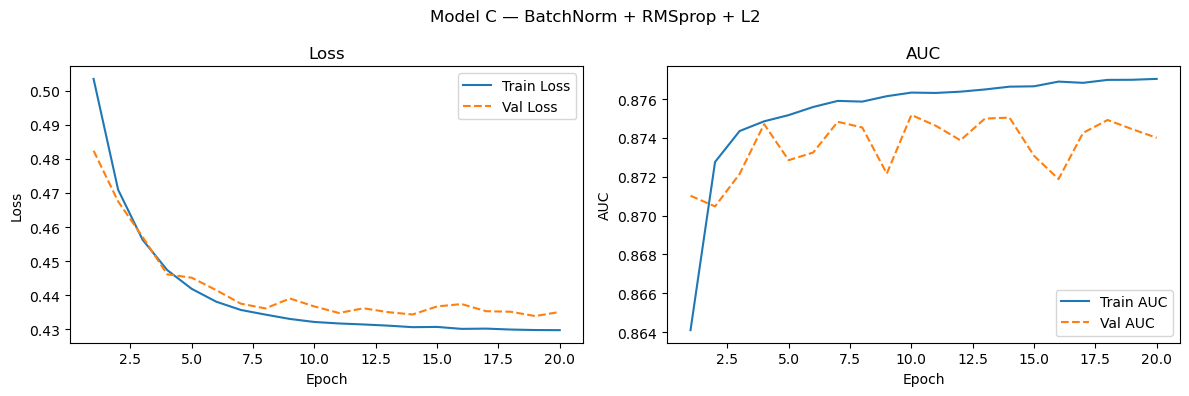

Last 5 val_loss range: 0.00352 — Model may still be improving — consider more epochs.
Final train/val loss gap: 0.00535 — No significant overfitting. ✓


In [10]:
#3a

from tensorflow.keras import regularizers

input_dim = X_Train_all_s.shape[1]

# Model A: Wide & Shallow — 2 hidden layers, 512 units each
def build_model_A(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation='relu'),
        layers.Dense(512, activation='relu'),
        layers.Dense(1,   activation='sigmoid')
    ], name="ModelA_Wide_Shallow")
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=[keras.metrics.AUC(name='auc')])
    return model

# Model B: Deep + Dropout — 5 layers with 30% dropout regularization
def build_model_B(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dense(64,  activation='relu'),
        layers.Dense(1,   activation='sigmoid')
    ], name="ModelB_Deep_Dropout")
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=[keras.metrics.AUC(name='auc')])
    return model

# Model C: BatchNorm + L2 + RMSprop — tests different optimizer and normalization
def build_model_C(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(300, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dense(300, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dense(300, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dense(1, activation='sigmoid')
    ], name="ModelC_BatchNorm_RMSprop_L2")
    model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=1e-3),
                  loss='binary_crossentropy',
                  metrics=[keras.metrics.AUC(name='auc')])
    return model

print("=== Model A: Wide & Shallow ===")
mA = build_model_A(input_dim)
mA.summary()
hA = mA.fit(X_Train_all_s, y_Train, **FIT_KWARGS)
plot_history(hA, "Model A — Wide & Shallow")

print("\n=== Model B: Deep with Dropout ===")
mB = build_model_B(input_dim)
mB.summary()
hB = mB.fit(X_Train_all_s, y_Train, **FIT_KWARGS)
plot_history(hB, "Model B — Deep + Dropout")

print("\n=== Model C: BatchNorm + RMSprop + L2 ===")
mC = build_model_C(input_dim)
mC.summary()
hC = mC.fit(X_Train_all_s, y_Train, **FIT_KWARGS)
plot_history(hC, "Model C — BatchNorm + RMSprop + L2")

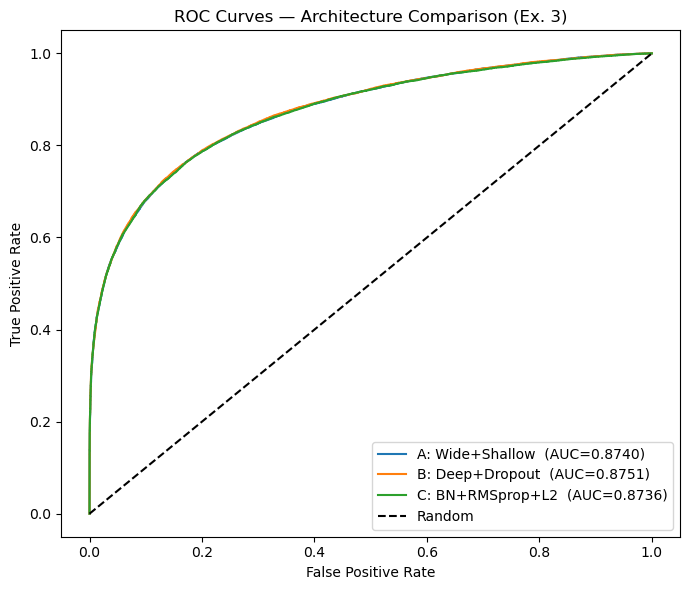

Model A: Wide+Shallow test AUC: 0.8740
Model B: Deep+Dropout test AUC: 0.8751
Model C: BN+RMSprop+L2 test AUC: 0.8736

Best DNN for Exercise 4: B: Deep+Dropout


In [11]:
#3b

# ROC comparison for the 3 architectures + picking the best model

plt.figure(figsize=(7, 6))
aucs = {}
for label, model in [("A: Wide+Shallow", mA), ("B: Deep+Dropout", mB), ("C: BN+RMSprop+L2", mC)]:
    y_score = model.predict(X_Test_all_s, verbose=0).ravel()
    fpr, tpr, _ = roc_curve(y_Test, y_score)
    aucs[label] = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label}  (AUC={aucs[label]:.4f})")

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Architecture Comparison (Ex. 3)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

for label, val in aucs.items():
    print(f"Model {label} test AUC: {val:.4f}")

best_label = max(aucs, key=aucs.get)
best_dnn   = {"A: Wide+Shallow": mA, "B: Deep+Dropout": mB, "C: BN+RMSprop+L2": mC}[best_label]
print(f"\nBest DNN for Exercise 4: {best_label}")

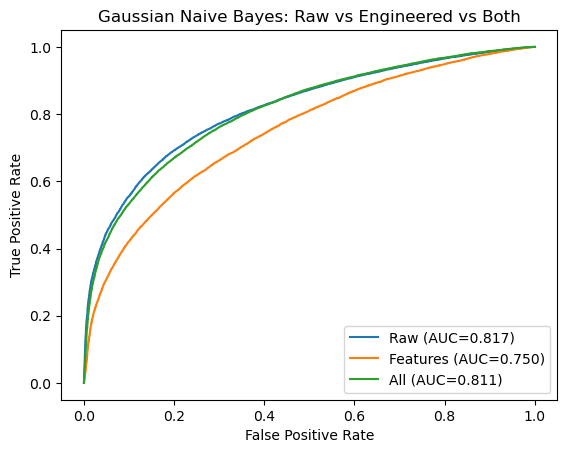

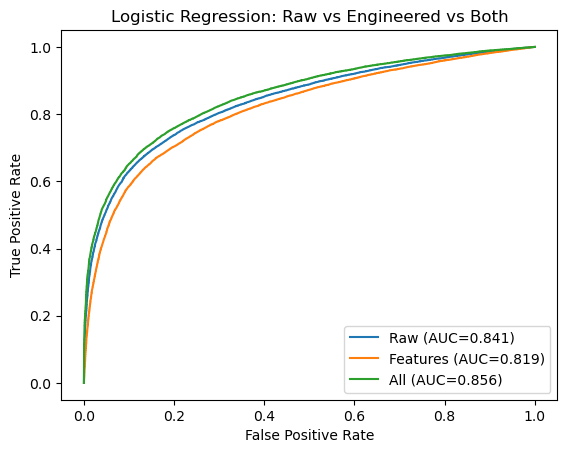

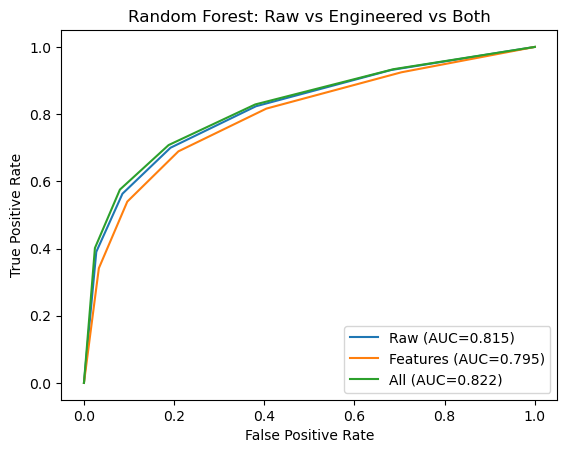

In [14]:
#4a

# repeating Lab 8 Ex4 but adding best DNN

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
import sklearn.base

scenarios = {
    "Raw":          RawNames,
    "Features":     FeatureNames,
    "All":          VarNames[1:]
}

clf1 = GaussianNB()
clf2 = LogisticRegression(max_iter=1000)
clf3 = RandomForestClassifier(n_estimators=5, n_jobs=-1, random_state=42)

def compare_classifier(clf, clf_name):
    plt.figure()
    for label, feats in scenarios.items():
        clf_copy = sklearn.base.clone(clf)
        clf_copy.fit(Train_Sample[feats], y_Train)

        if hasattr(clf_copy, "decision_function"):
            scores = clf_copy.decision_function(Test_Sample[feats])
        else:
            scores = clf_copy.predict_proba(Test_Sample[feats])[:, 1]

        fpr, tpr, _ = roc_curve(y_Test, scores)
        plt.plot(fpr, tpr, label=f'{label} (AUC={auc(fpr,tpr):.3f})')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{clf_name}: Raw vs Engineered vs Both')
    plt.legend(loc='lower right')
    plt.show()

compare_classifier(clf1, "Gaussian Naive Bayes")
compare_classifier(clf2, "Logistic Regression")
compare_classifier(clf3, "Random Forest")

Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s -15672us/step - auc: 0.8364 - loss: 0.4863 - val_auc: 0.8658 - val_loss: 0.4422
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - auc: 0.8586 - loss: 0.4526 - val_auc: 0.8676 - val_loss: 0.4416
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - auc: 0.8614 - loss: 0.4487 - val_auc: 0.8695 - val_loss: 0.4365
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - auc: 0.8639 - loss: 0.4454 - val_auc: 0.8704 - val_loss: 0.4355
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc: 0.8642 - loss: 0.4445 - val_auc: 0.8700 - val_loss: 0.4348
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - auc: 0.8657 - loss: 0.4422 - val_auc: 0.8703 - val_loss: 0.4366
Epoch 7/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc: 0.8668 - loss: 0.4405 - val_auc: 0.8713 - val_loss: 0.4344
Epoch 8/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc: 0.8669 - loss: 0.4409 - val_auc: 0.8708 - val_loss: 0.4345
Epoch 9/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc: 0.

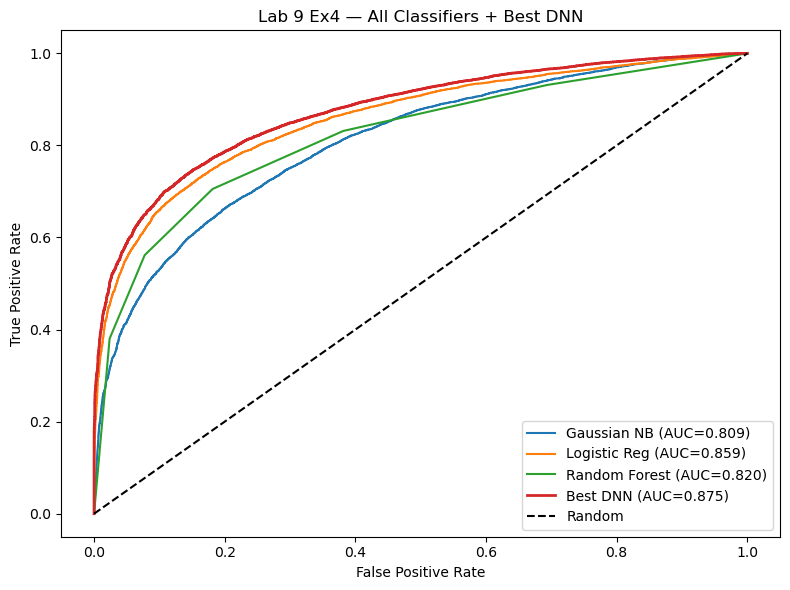

In [15]:
# 4b

# Now adding the best DNN to the comparison
N_small    = 100000
Train_Small = df[:N_small]
Test_Small  = df[N_small:N_small+20000]

all_features = VarNames[1:]

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_tr = sc.fit_transform(Train_Small[all_features])
X_te = sc.transform(Test_Small[all_features])
y_tr = Train_Small["signal"].values
y_te = Test_Small["signal"].values

# Training best DNN on this subset
best_dnn_ex4 = build_model_B(X_tr.shape[1])   # swap to whichever was best in Ex3
best_dnn_ex4.fit(X_tr, y_tr, epochs=20, batch_size=1024, validation_split=0.1, verbose=1)

# Significance plot (same as Lab 8 4c)
scores_dnn = best_dnn_ex4.predict(X_te, verbose=0).ravel()
fpr_arr, tpr_arr, thresholds = roc_curve(y_te, scores_dnn)

N_S = tpr_arr * (y_te == 1).sum()
N_B = fpr_arr * (y_te == 0).sum()

with np.errstate(invalid='ignore'):
    significance = N_S / np.sqrt(N_S + N_B)

max_idx = np.nanargmax(significance)
print(f"Best DNN — Max significance: {significance[max_idx]:.2f}")
print(f"At threshold:  {thresholds[max_idx]:.4f}")
print(f"TPR: {tpr_arr[max_idx]:.3f}  |  FPR: {fpr_arr[max_idx]:.3f}")

# ROC overlay: all classifiers + DNN
plt.figure(figsize=(8,6))
for label, clf in [("Gaussian NB", clf1), ("Logistic Reg", clf2), ("Random Forest", clf3)]:
    clf_copy = sklearn.base.clone(clf)
    clf_copy.fit(Train_Small[all_features], y_tr)
    if hasattr(clf_copy, "decision_function"):
        s = clf_copy.decision_function(Test_Small[all_features])
    else:
        s = clf_copy.predict_proba(Test_Small[all_features])[:, 1]
    fpr, tpr, _ = roc_curve(y_te, s)
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc(fpr,tpr):.3f})")

plt.plot(fpr_arr, tpr_arr, label=f"Best DNN (AUC={auc(fpr_arr,tpr_arr):.3f})", linewidth=2)
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Lab 9 Ex4 — All Classifiers + Best DNN')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Used claude to generate the part from # ROC overlay to plt.plot(fpr,... part